In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime

# ETFs - Goals
Before we start to compare which ETFs are good and which not, we first may need to set common goals on what we expect investing in ETFs. It's cleear that you will not make big money in a short period of time by diversifying your portfolio with ETFs - for those risky and high-reward investments, buy crypto or whatever. For many, ETFs are a long-term investment that you keep around in your portfolio for a long time. There are even some financial experts saying that you should by into an (passive) ETF and forget about it. So generally, investing into ETFs requires *patience*. Not only that, we also have to have the strong, unbreakable *belief* that the ETF we invest in will rise in value on long-term. So let's test, which ETFs are most trusted in rising in value, but also will not take half your life, just to recover from a financial crash.

## Passive ETFs
Now, let's see, which ETFs are worth considering and why

In [9]:
# Define the big ETFs everyone talks about
# Ticker -> Name/Description
popular_etfs = {
    # US Market - S&P 500
    "SPY": "SPDR S&P 500 ETF (US)",
    # US Market - NASDAQ-100
    "QQQ": "Invesco QQQ Trust (NASDAQ-100, US)",
    # Biggest, most diversified
    "ACIM": "MSCI All World (everything, focus on US)",
    # Emerging markets
    "EEM": "Emerging markets (China, India, Brazil, etc)",
    # semiconductors
    "SMH": "VanEck Semiconductors",
    # "baseline": gold
    "EGLN.L": "Gold"
}

## ETFs — Same Start Date, All Normalized to 100

Now we align all ETFs to start from the **same point in time** (today − MIN_YEARS). This way, every ETF begins at the same date — no matter how long it has existed — and we normalise its price to **100** at that point. This makes the trajectories truly comparable.

Common start date: 2001-06-28  (today − 25 years)
Any ETF without data going back to 2001-06-28 will be excluded.

SPY (SPDR S&P 500 ETF (US)) — data since 1993-01-29  (6284 trading days)
QQQ (Invesco QQQ Trust (NASDAQ-100, US)) — data since 1999-03-10  (6284 trading days)
ACIM (MSCI All World (everything, focus on US)) — only since 2012-03-05 (too young)
EEM (Emerging markets (China, India, Brazil, etc)) — only since 2003-04-14 (too young)
SMH (VanEck Semiconductors) — data since 2000-06-05  (6284 trading days)
EGLN.L (Gold) — only since 2011-04-08 (too young)
3 ETF(s) qualify — all start from 2001-06-28.


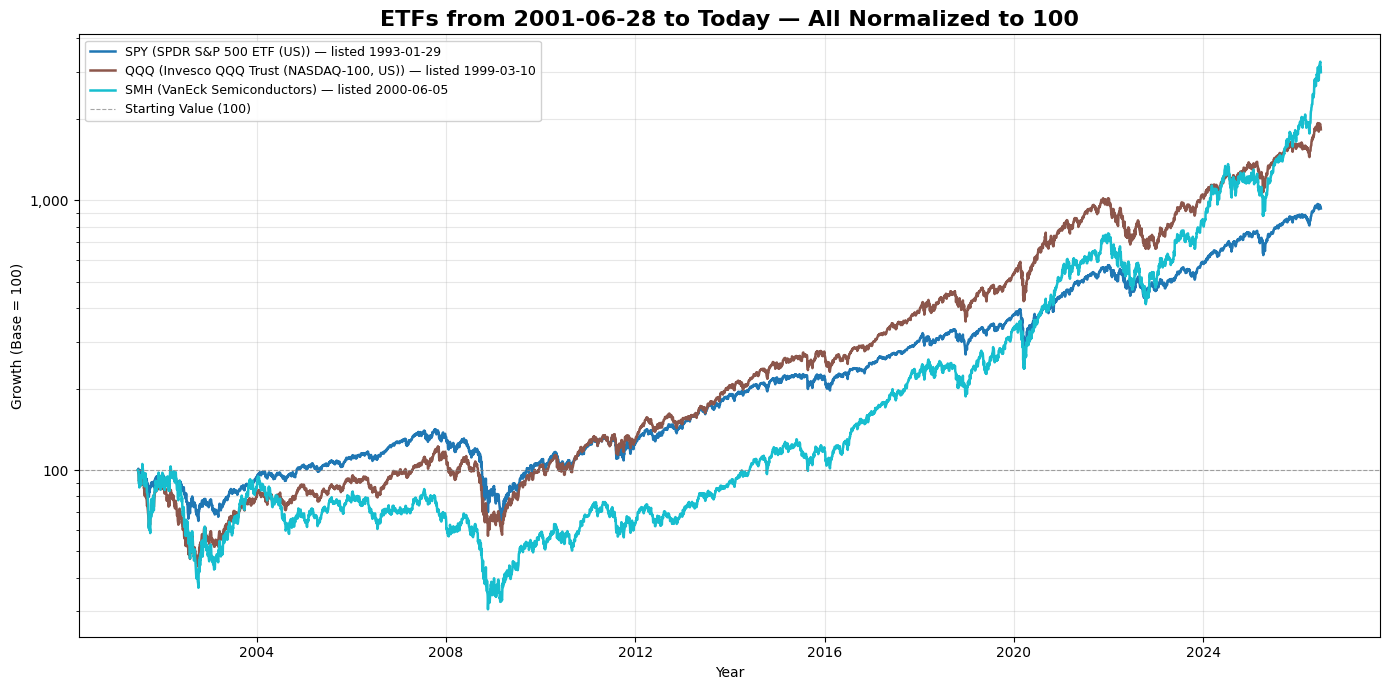


SUMMARY: Growth Since the Common Start Date


,Listed Since,Trading Days,Start Price,Current Price,Total Growth,CAGR
ETF,,,,,,
SPY,1993-01-29,6284,$78.06,$728.99,833.9%,9.37%
QQQ,1999-03-10,6284,$38.51,$706.52,1734.7%,12.38%
SMH,2000-06-05,6284,$20.46,$611.61,2888.6%,14.60%


In [10]:
MIN_YEARS = 25

# Compute the common start date: today minus MIN_YEARS
today = datetime.today()
common_start = today.replace(year=today.year - MIN_YEARS)
print(f"Common start date: {common_start.strftime('%Y-%m-%d')}  (today − {MIN_YEARS} years)")
print(f"Any ETF without data going back to {common_start.strftime('%Y-%m-%d')} will be excluded.\n")

# Download all historical data (adjusted close)
all_data = yf.download(
    list(popular_etfs.keys()),
    period="max",
    auto_adjust=True,
    progress=False,
)

# Extract 'Close' prices
if len(popular_etfs) > 1:
    closes = all_data["Close"]
else:
    closes = all_data[["Close"]]

# Filter: keep only ETFs that existed before the common start date
valid = {}
for ticker, name in popular_etfs.items():
    series = closes[ticker].dropna()
    first_date = series.index[0]
    
    if first_date <= common_start:
        # Slice from common_start onwards
        sliced = series[series.index >= common_start]
        valid[ticker] = {"name": name, "series": sliced, "start": first_date.strftime("%Y-%m-%d")}
        print(f"{ticker} ({name}) — data since {first_date.strftime('%Y-%m-%d')}  ({len(sliced)} trading days)")
    else:
        print(f"{ticker} ({name}) — only since {first_date.strftime('%Y-%m-%d')} (too young)")

if not valid:
    print(f"No ETF existed before {common_start.strftime('%Y-%m-%d')}! Try a lower MIN_YEARS.")
else:
    print(f"{len(valid)} ETF(s) qualify — all start from {common_start.strftime('%Y-%m-%d')}.")

    # ---- Normalize & Plot ----
    fig, ax = plt.subplots(figsize=(14, 7))

    colors = plt.cm.tab10(np.linspace(0, 1, len(valid)))

    for (ticker, data), color in zip(valid.items(), colors):
        series = data["series"]
        # Normalise: first price in the common window = 100
        normalized = series / series.iloc[0] * 100
        label = f"{ticker} ({data['name']}) — listed {data['start']}"
        ax.plot(normalized.index, normalized, label=label, color=color, linewidth=1.8)

    # Baseline at 100
    ax.axhline(y=100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Starting Value (100)")

    ax.set_title(f"ETFs from {common_start.strftime('%Y-%m-%d')} to Today — All Normalized to 100", fontsize=16, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Growth (Base = 100)")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

    # ---- Summary table ----
    print("\n" + "=" * 90)
    print("SUMMARY: Growth Since the Common Start Date")
    print("=" * 90)
    summary_rows = []
    for ticker, data in valid.items():
        s = data["series"]
        years = len(s) / 252
        summary_rows.append({
            "ETF": ticker,
            "Listed Since": data["start"],
            "Trading Days": len(s),
            "Start Price": f"${s.iloc[0]:.2f}",
            "Current Price": f"${s.iloc[-1]:.2f}",
            "Total Growth": f"{(s.iloc[-1] / s.iloc[0] - 1) * 100:.1f}%",
            "CAGR": f"{((s.iloc[-1] / s.iloc[0]) ** (252 / len(s)) - 1) * 100:.2f}%",
        })
    display(pd.DataFrame(summary_rows).set_index("ETF"))